2026-09-01 15:40:35.279 | INFO     | __main__:llm_node:51 - 当前用户的名字：Alice，登级： VIP


{'messages': [], 'user_input': '你好，帮我查一下最近又哪些优惠活动', 'output': ChatPromptTemplate(input_variables=[], input_types={}, partial_variables={}, messages=[AIMessage(content='尊敬的Alice，您好！非常荣幸能为您服务。请问今天有什么我可以为您效劳的？无论是咨询、预订还是其他需求，我都会竭尽全力为您提供最细致、周到的支持。愿您度过愉快的一天！VIP服务专线为您时刻在线。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 31, 'total_tokens': 85, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 31}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': '06160d4b-247f-42a3-8acd-96a851708aec', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a05be9-aa57-7e11-ba66-8a48527a6a32-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 31, 'output_tokens'

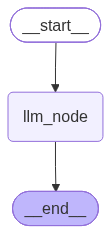

In [4]:
from langgraph.runtime import Runtime
import time
from dataclasses import dataclass
from operator import add
from langchain_core.messages import ToolMessage, SystemMessage
from random import randint

from langchain_core.runnables import RunnableConfig
from langgraph.cache.memory import InMemoryCache
from langgraph.errors import GraphRecursionError
from langgraph.graph import MessagesState

from multiprocessing import resource_tracker, context

from langgraph.graph import StateGraph, START, END, MessagesState, MessageGraph
from typing import TypedDict, Literal, Sequence, Annotated, Final, Tuple
from IPython.display import display
from langchain_deepseek import ChatDeepSeek
from dotenv import load_dotenv
from langchain.tools import tool
from langgraph.managed.is_last_step import RemainingSteps
from loguru import logger
from langgraph.types import Send, Command, CachePolicy
from langchain.messages import HumanMessage, AIMessage, SystemMessage
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    # temperature=0.7,
    extra_body={
        "thinking": {
            "type": "disabled",
        }
    }
)

@dataclass
class UserContext:
    username: str
    membership_level: str

class OverAllState(MessagesState):
    user_input: str
    output: str

def llm_node(state:OverAllState, runtime:Runtime[UserContext]) -> OverAllState:
    runtime_context=runtime.context
    if runtime_context:
            level= runtime_context.membership_level
            username = runtime_context.username
            logger.info(f"当前用户的名字：{username}，登级： {level}")
            if level == "VIP":
                system_prompt = f"你是高级客户助理，当前VIP用户是{username}，请使用尊称“您，语气热情周到，末尾回复添加VIP服务。"
            else:
                system_prompt = f"你是普通客户助理，当前用户是{username}，请友好简洁回复。"
    else:
        system_prompt = f"你是普通客户助理，当前用户是游客，请友好简洁回复。"
    user_input = state["user_input"]
    messages = state.get("messages",[])
    response = model.invoke([SystemMessage(system_prompt)] + messages) + [HumanMessage(content=user_input)]
    return {
        "messages": messages,
        "output": response
    }

builder = StateGraph(state_schema=OverAllState,context=UserContext)

builder.add_node("llm_node",llm_node)
builder.add_edge(START, "llm_node")
builder.add_edge("llm_node", END)

graph = builder.compile()
res = graph.invoke(
    {"user_input": "你好，帮我查一下最近又哪些优惠活动"},
    context=UserContext(username="Alice",membership_level="VIP")
)
print(res)
display(graph)




In [5]:
res = graph.invoke(
    {"user_input": "你好，帮我查一下最近又哪些优惠活动"},
    context=UserContext(username="Alice",membership_level="普通用户")
)
print(res)

2026-09-01 15:43:26.931 | INFO     | __main__:llm_node:51 - 当前用户的名字：Alice，登级： 普通用户


{'messages': [], 'user_input': '你好，帮我查一下最近又哪些优惠活动', 'output': ChatPromptTemplate(input_variables=[], input_types={}, partial_variables={}, messages=[AIMessage(content='您好，Alice！我是您的客户助理，有什么可以帮您的吗？随时告诉我哦。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 18, 'total_tokens': 37, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 18}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': 'a9393dd9-383b-4ee9-ac77-6ecc60a1ff5f', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a05bec-48d4-7671-b4ae-8dc16adaaecc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 19, 'total_tokens': 37, 'input_token_details': {'cache_read':